<a href="https://colab.research.google.com/github/Wejdan999/T55/blob/main/week3_Copy_of_Clustering_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering and Dimensionality Reduction Exam
Welcome to the weekly project on clustering and dimensionality reduction. You will be working with a dataset of traffic accidents.

## Dataset
The dataset that will be used in this task is `Traffic_Accidents.csv`

## Instructions
- Follow the steps outlined below.
- Write your code in the empty code cells.
- Comment on your code to explain your reasoning.

## Dataset Overview
The dataset contains information about traffic accidents, including location, weather conditions, road conditions, and more. Below are sample of these columns:

* `Location_Easting_OSGR`: Easting coordinate of the accident location.
* `Location_Northing_OSGR`: Northing coordinate of the accident location.
* `Longitude`: Longitude of the accident site.
* `Latitude`: Latitude of the accident site.
* `Police_Force`: Identifier for the police force involved.
* `Accident_Severity`: Severity of the accident.
* `Number_of_Vehicles`: Number of vehicles involved in the accident.
* `Number_of_Casualties`: Number of casualties in the accident.
* `Date`: Date of the accident.
* `Day_of_Week`: Day of the week when the accident occurred.
* `Speed_limit`: Speed limit in the area where the accident occurred.
* `Weather_Conditions`: Weather conditions at the time of the accident.
* `Road_Surface_Conditions`: Condition of the road surface during the accident.
* `Urban_or_Rural_Area`: Whether the accident occurred in an urban or rural area.
* `Year`: Year when the accident was recorded.
* Additional attributes related to road type, pedestrian crossing, light conditions, etc.

## Goal
The primary goal is to analyze the accidents based on their geographical location.


## Import Libraries

In [119]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import mutual_info_score, adjusted_rand_score

## Load the Data

In [120]:
ta=pd.read_csv('/content/Traffic_Accidents.csv')

In [121]:
ta.head()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,...,2nd_Road_Class,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year
0,560530.0,103950.0,0.277298,50.812789,47,3.0,1,1.0,27/11/2009,6,...,-1,0,None within 50 metres,No physical crossing within 50 meters,Darkeness: No street lighting,Raining with high winds,Flood (Over 3cm of water),2.0,Yes,2009
1,508860.0,187170.0,-0.430574,51.572846,1,3.0,2,1.0,10/10/2010,1,...,6,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,1.0,Yes,2010
2,314460.0,169130.0,-3.231459,51.414661,62,3.0,2,1.0,14/09/2005,4,...,3,4055,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,1.0,Yes,2005
3,341700.0,408330.0,-2.881800,53.568318,4,3.0,1,2.0,18/08/2007,7,...,6,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Raining without high winds,Wet/Damp,1.0,Yes,2007
4,386488.0,350090.0,-2.203020,53.047882,21,3.0,2,2.0,06/08/2013,3,...,-1,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,1.0,Yes,2013


## Exploratory Data Analysis (EDA)
Perform EDA to understand the data better. This involves several steps to summarize the main characteristics, uncover patterns, and establish relationships:
* Find the dataset information and observe the datatypes.
* Check the shape of the data to understand its structure.
* View the the data with various functions to get an initial sense of the data.
* Perform summary statistics on the dataset to grasp central tendencies and variability.
* Check for duplicated data.
* Check for null values.

And apply more if needed!


In [122]:
ta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 26 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Location_Easting_OSGR                        52000 non-null  float64
 1   Location_Northing_OSGR                       52000 non-null  float64
 2   Longitude                                    52000 non-null  float64
 3   Latitude                                     52000 non-null  float64
 4   Police_Force                                 52000 non-null  int64  
 5   Accident_Severity                            51678 non-null  float64
 6   Number_of_Vehicles                           52000 non-null  int64  
 7   Number_of_Casualties                         50959 non-null  float64
 8   Date                                         52000 non-null  object 
 9   Day_of_Week                                  52000 non-null  int64  
 10

In [123]:
ta.describe()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Urban_or_Rural_Area,Year
count,52000.000000,5.200000e+04,52000.000000,52000.000000,52000.000000,51678.000000,52000.000000,50959.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,52000.000000,51912.000000,52000.000000
mean,440284.256846,2.998617e+05,-1.427193,52.586684,30.401712,2.837145,1.834327,1.354756,4.130712,349.542558,4.080519,997.078077,39.148558,2.672673,384.503058,1.359397,2009.401788
std,95109.751221,1.613624e+05,1.398249,1.453049,25.545581,0.402582,0.727856,0.855220,1.926217,259.504721,1.428056,1806.405065,14.212826,3.205080,1304.989395,0.479868,3.006997
min,98480.000000,1.903000e+04,-6.895268,50.026153,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,15.000000,-1.000000,-1.000000,1.000000,2005.000000
25%,375540.000000,1.780100e+05,-2.366190,51.487676,7.000000,3.000000,1.000000,1.000000,2.000000,112.000000,3.000000,0.000000,30.000000,-1.000000,0.000000,1.000000,2006.000000
50%,440950.000000,2.671800e+05,-1.391202,52.295042,30.000000,3.000000,2.000000,1.000000,4.000000,323.000000,4.000000,128.500000,30.000000,3.000000,0.000000,1.000000,2010.000000
75%,523500.000000,3.981492e+05,-0.214666,53.478016,46.000000,3.000000,2.000000,1.000000,6.000000,530.000000,6.000000,716.000000,50.000000,6.000000,0.000000,2.000000,2012.000000
max,654960.000000,1.203900e+06,1.753632,60.714774,98.000000,3.000000,34.000000,51.000000,7.000000,941.000000,6.000000,9999.000000,70.000000,6.000000,9999.000000,3.000000,2014.000000


In [124]:
ta.duplicated().sum()

43

In [125]:
ta=ta.drop_duplicates()

In [126]:
ta.isna().sum()

,0
Location_Easting_OSGR,0
Location_Northing_OSGR,0
Longitude,0
Latitude,0
Police_Force,0
Accident_Severity,322
Number_of_Vehicles,0
Number_of_Casualties,1041
Date,0
Day_of_Week,0


## Data Preprocessing
Do what you think you need such as:
* Remove the outliers
* Impute missing data
* Scale the data
* Reduce dimentions using PCA
* Implement One-Hot Encoding for nominal categorical variables.

<Axes: ylabel='1st_Road_Number'>

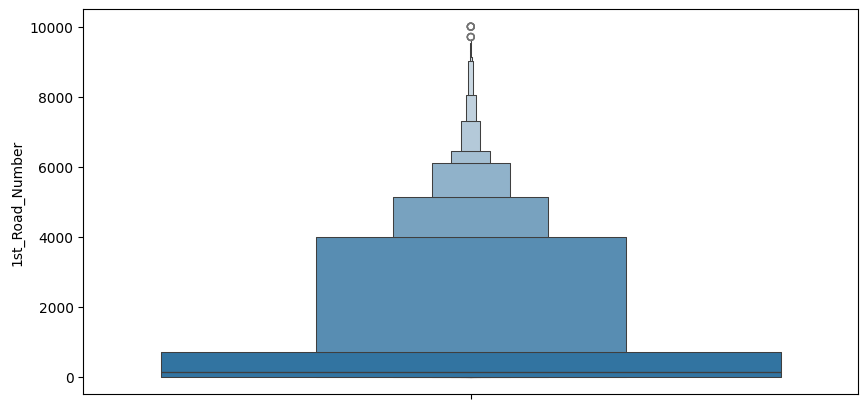

In [127]:
sns.boxenplot(ta['1st_Road_Number'])

In [128]:
q1=ta['1st_Road_Number'].quantile(0.25)
q3=ta['1st_Road_Number'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+0.5*iqr
ta2=ta[(ta['1st_Road_Number']>=lower_bound) & (ta['1st_Road_Number']<=upper_bound)]


<Axes: ylabel='1st_Road_Number'>

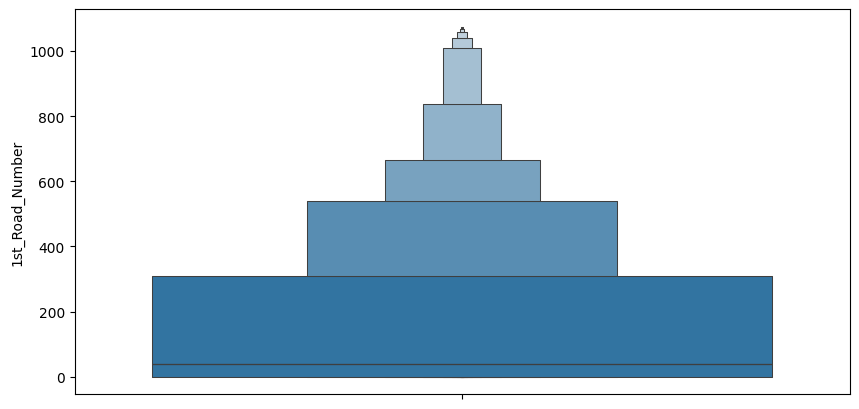

In [129]:
sns.boxenplot(ta2['1st_Road_Number'])

In [130]:
#Impute missing data
ta2.fillna(ta2['Accident_Severity'].mean, inplace=True)

ta2.fillna(ta2['Number_of_Casualties'].mean, inplace=True)

ta2.fillna(ta2['Light_Conditions'].mode, inplace=True)

ta2.fillna(ta2['Urban_or_Rural_Area'].mean, inplace=True)

<ipython-input-130-ebe73708d52e>:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<bound method Series.mean of 0        3.0
1        3.0
2        3.0
3        3.0
4        3.0
        ... 
51995    3.0
51996    3.0
51997    3.0
51998    3.0
51999    3.0
Name: Accident_Severity, Length: 40870, dtype: float64>' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  ta2.fillna(ta2['Accident_Severity'].mean, inplace=True)
<ipython-input-130-ebe73708d52e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ta2.fillna(ta2['Accident_Severity'].mean, inplace=True)
<ipython-input-130-ebe73708d52e>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats i

In [131]:
ta2.isna().sum()

,0
Location_Easting_OSGR,0
Location_Northing_OSGR,0
Longitude,0
Latitude,0
Police_Force,0
Accident_Severity,0
Number_of_Vehicles,0
Number_of_Casualties,0
Date,0
Day_of_Week,0


## Feature Selection
Select relevant features for clustering. Explain your choice of features.


In [132]:
#Location_Easting_OSGR
#Location_Northing_OSGR


## Data Visualization
Visualize the data using appropriate plots to gain insights into the dataset. Using the following:
- Scatter plot of accidents based on Longitude and Latitude.

In [133]:
ta2.columns

Index(['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude',
       'Latitude', 'Police_Force', 'Accident_Severity', 'Number_of_Vehicles',
       'Number_of_Casualties', 'Date', 'Day_of_Week',
       'Local_Authority_(District)', 'Local_Authority_(Highway)',
       '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit',
       '2nd_Road_Class', '2nd_Road_Number',
       'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions', 'Urban_or_Rural_Area',
       'Did_Police_Officer_Attend_Scene_of_Accident', 'Year'],
      dtype='object')

In [134]:
ta['Accident_Severity'].value_counts()

,count
Accident_Severity,
3.0,43890
2.0,7080
1.0,665


<Axes: xlabel='Longitude', ylabel='Latitude'>

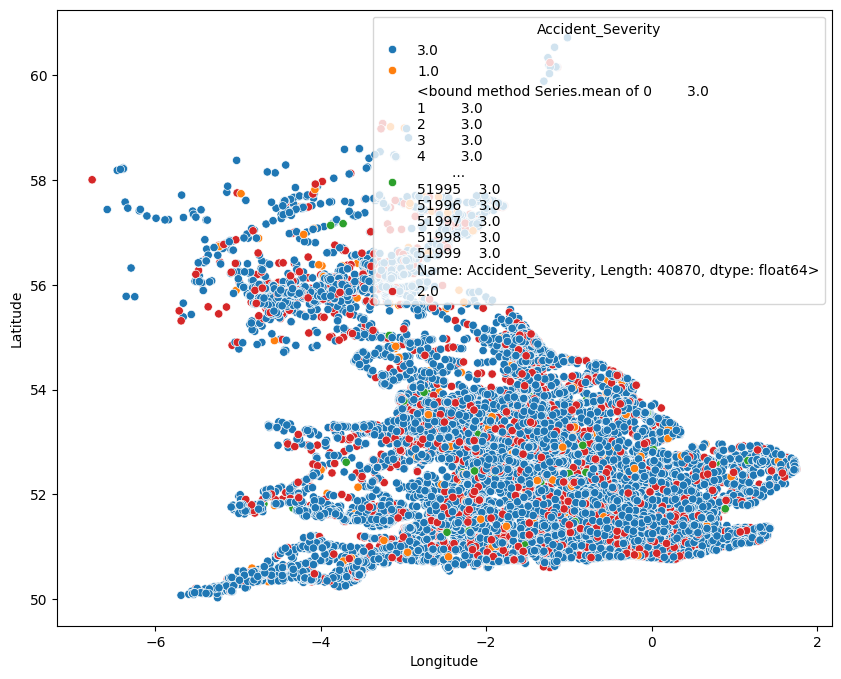

In [135]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=ta2, x='Longitude',y='Latitude', hue='Accident_Severity')

Most of the accident between 54-50 and -6-2

In [136]:
ta2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40870 entries, 0 to 51999
Data columns (total 26 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Location_Easting_OSGR                        40870 non-null  float64
 1   Location_Northing_OSGR                       40870 non-null  float64
 2   Longitude                                    40870 non-null  float64
 3   Latitude                                     40870 non-null  float64
 4   Police_Force                                 40870 non-null  int64  
 5   Accident_Severity                            40870 non-null  object 
 6   Number_of_Vehicles                           40870 non-null  int64  
 7   Number_of_Casualties                         40870 non-null  object 
 8   Date                                         40870 non-null  object 
 9   Day_of_Week                                  40870 non-null  int64  
 10  Loc

In [137]:
ta2.columns

Index(['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude',
       'Latitude', 'Police_Force', 'Accident_Severity', 'Number_of_Vehicles',
       'Number_of_Casualties', 'Date', 'Day_of_Week',
       'Local_Authority_(District)', 'Local_Authority_(Highway)',
       '1st_Road_Class', '1st_Road_Number', 'Road_Type', 'Speed_limit',
       '2nd_Road_Class', '2nd_Road_Number',
       'Pedestrian_Crossing-Human_Control',
       'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       'Weather_Conditions', 'Road_Surface_Conditions', 'Urban_or_Rural_Area',
       'Did_Police_Officer_Attend_Scene_of_Accident', 'Year'],
      dtype='object')

'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude',
       'Latitude', 'Police_Force', 'Number_of_Vehicles',
        'Day_of_Week',
       'Local_Authority_(District)',
       '1st_Road_Class', '1st_Road_Number', 'Speed_limit',
       '2nd_Road_Class', '2nd_Road_Number',
        'Year'

In [138]:
#x_cat=ta2[['Number_of_Casualties','Date','Local_Authority_(Highway)','Road_Type'
                                #   ,'Pedestrian_Crossing-Human_Control','Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions',
       #'Weather_Conditions', 'Road_Surface_Conditions', 'Urban_or_Rural_Area','Did_Police_Officer_Attend_Scene_of_Accident',]]

In [139]:
#oh=OneHotEncoder()
#oh.fit(x_cat)


In [140]:
x=ta2[['Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force',
                                    'Number_of_Vehicles', 'Day_of_Week','Local_Authority_(District)',  '1st_Road_Class', '1st_Road_Number',
                                    'Speed_limit','2nd_Road_Class', '2nd_Road_Number', 'Year']]

In [141]:
x_train,x_test=train_test_split(x,test_size=0.2,random_state=42)

In [142]:
x_mean=x.mean()
x_std=x.std()
x_scaled=(x-x_mean)/x_std
x_scaled.head()

,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Number_of_Vehicles,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Year
0,1.250480,-1.195218,1.204927,-1.201757,0.614296,-1.124663,0.971811,0.768756,-0.746100,-0.612178,2.060055,-1.118789,-0.261634,-0.124810
1,0.714635,-0.696858,0.706692,-0.696190,-1.109735,0.221349,-1.622673,-1.203178,-0.091123,1.103497,-0.660711,1.061123,-0.261634,0.207479
2,-1.301393,-0.804889,-1.264706,-0.801410,1.176480,0.221349,-0.065983,1.475675,1.218831,-0.697189,-0.660711,0.126875,3.353557,-1.453965
3,-1.018900,0.627552,-1.018599,0.631135,-0.997298,-1.124663,1.490708,-0.987382,1.218831,-0.697189,-0.660711,1.061123,-0.261634,-0.789387
4,-0.554426,0.278784,-0.540841,0.284958,-0.360156,0.221349,-0.584879,-0.343713,1.218831,-0.697189,-0.660711,-1.118789,-0.261634,1.204346


In [143]:
pca = PCA(n_components=2)
pca.fit(x_scaled)
cc_pca = pca.transform(x_scaled)
print(cc_pca)

[[-1.26796469  2.83610682]
 [-2.12755444 -0.63980174]
 [ 1.45555386 -0.4571611 ]
 ...
 [-1.34465923  0.47999489]
 [-0.00593187 -1.09917823]
 [-0.12800082  2.559198  ]]


## Clustering
Apply K-Means clustering. Determine the optimal number of clusters and justify your choice.
* Find the `n_clusters` parameter using the elbow method.
* Train the model.

In [144]:
from sklearn.cluster import KMeans
elbow=[]
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 101)
    kmeans.fit(cc_pca)
    elbow.append(kmeans.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

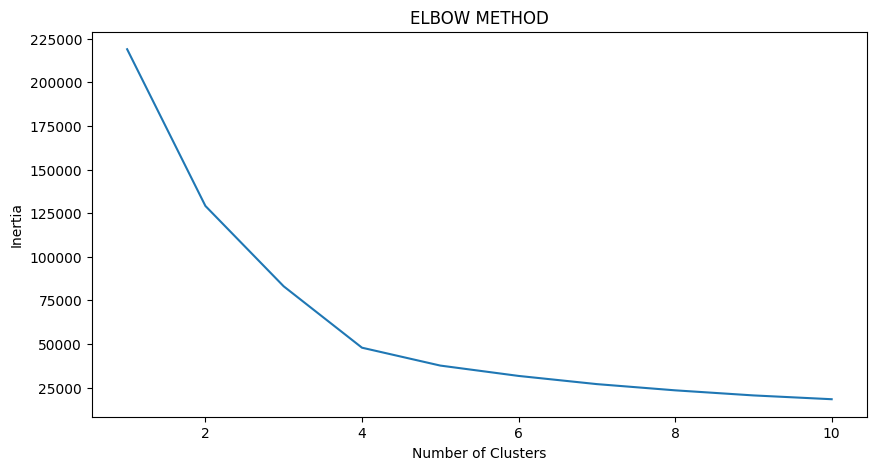

In [145]:
x_range = range(1, 11)

sns.lineplot(x=x_range, y=elbow)
plt.rcParams.update({'figure.figsize':(10,5), 'figure.dpi':100})
plt.title('ELBOW METHOD')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [146]:
kmeans = KMeans(n_clusters = 4, random_state = 2)
kmeans.fit(x)
kmeans.cluster_centers_


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([[ 4.09021102e+05,  3.82064595e+05, -1.86577572e+00,
         5.33328821e+01,  1.66041961e+01,  1.84547105e+00,
         4.13832291e+00,  2.24468966e+02,  4.28000807e+00,
         1.84183982e+02,  3.91318674e+01,  2.73525654e+00,
         3.61420147e+02,  2.00930455e+03],
       [ 5.29891767e+05,  1.86075253e+05, -1.26205058e-01,
         5.15570090e+01,  2.57777976e+01,  1.84636905e+00,
         4.10922619e+00,  2.86532679e+02,  3.93607143e+00,
         1.68888214e+02,  3.89785714e+01,  2.71398810e+00,
         2.55645476e+02,  2.00949881e+03],
       [ 3.27768042e+05,  1.46358187e+05, -3.03244129e+00,
         5.12079383e+01,  5.26985676e+01,  1.86879801e+00,
         4.15009342e+00,  6.21116878e+02,  4.40523147e+00,
         1.25940212e+02,  4.22565912e+01,  2.16504048e+00,
         1.99072244e+02,  2.00921445e+03],
       [ 3.23402974e+05,  6.60152040e+05, -3.23122772e+00,
         5.58235042e+01,  7.23815609e+01,  1.72387038e+00,
         4.13281607e+00,  7.15523277e+02,  4.

In [147]:
pred = kmeans.fit_predict(x)
pred

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


array([1, 1, 2, ..., 1, 0, 1], dtype=int32)

## Evaluation
Evaluate the clustering result using appropriate metrics.


In [148]:
silhouette = silhouette_score(x, kmeans.labels_)
db_index = davies_bouldin_score(x, kmeans.labels_)
ch_index = calinski_harabasz_score(x, kmeans.labels_)

print(f"Silhouette Score: {silhouette:.2f}")
print(f"Davies-Bouldin Index: {db_index:.2f}")
print(f"Calinski-Harabasz Index: {ch_index:.2f}")



Silhouette Score: 0.56
Davies-Bouldin Index: 0.60
Calinski-Harabasz Index: 69302.75


## Plot the data points with their predicted cluster center

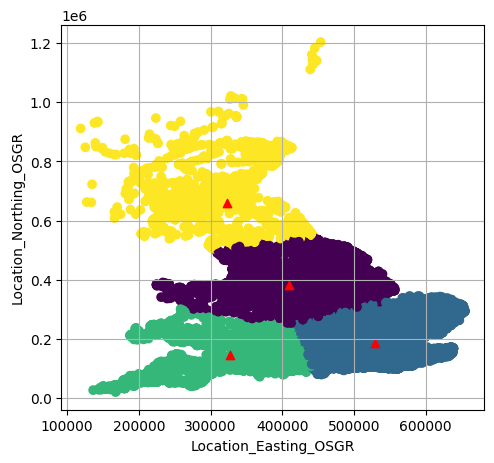

In [149]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,2)

plt.scatter(x.iloc[:,0], x.iloc[:,1], c=pred)
plt.grid(True)
for center in kmeans.cluster_centers_:
    center = center[:2]
    plt.scatter(center[0],center[1],marker = '^',c = 'red')
plt.xlabel("Location_Easting_OSGR")
plt.ylabel("Location_Northing_OSGR")
plt.show()


## Exam Questions
* **Justify Your Feature Selection:**
   - Which features did you choose for clustering and why?
* **Number of Clusters Choices:**
   - How did you determine the optimal number?
* **Evaluation:**
   - Which metrics did you use to evaluate the clustering results, and why?
   - How do these metrics help in understanding the effectiveness of your clustering approach?
* **Improvements and Recommendations:**
   - Suggest any improvements or future work that could be done with this dataset. What other methods or algorithms would you consider applying?

I choose Location_Easting_OSGR and Location_Northing_OSGR which I see the perfect feature to do clustring.
Based on elbow method I see that 4 clustering is the best.
I use silhouette_score, davies_bouldin_score and calinski_harabasz_score, it gave me score between 56-60% and it is good.  